In [89]:
# Upload Files
from google.colab import files
uploaded = files.upload()

Saving Obs_Temp_Min_Processed.xlsx to Obs_Temp_Min_Processed.xlsx


In [21]:
# Upload Files
from google.colab import files
uploaded = files.upload()

Saving temp_day_MPI-ESM1-2-HR_ssp245.xlsx to temp_day_MPI-ESM1-2-HR_ssp245 (1).xlsx
Saving temp_day_MPI-ESM1-2-HR_historical.xlsx to temp_day_MPI-ESM1-2-HR_historical (1).xlsx


In [35]:
from google.colab import files
uploaded = files.upload()

Saving temp_day_MPI-ESM1-2-HR_ssp585.xlsx to temp_day_MPI-ESM1-2-HR_ssp585.xlsx


Sectionn one

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_additive_qdm(obs_vals, gcm_h_vals, gcm_f_vals):
    """
    QDM Algorithm for Temperature (Additive)
    Ensures climate trends are preserved while correcting bias.
    """
    # 1. Clean data
    obs_vals = obs_vals[~np.isnan(obs_vals)]
    gcm_h_vals = gcm_h_vals[~np.isnan(gcm_h_vals)]
    gcm_f_vals = gcm_f_vals[~np.isnan(gcm_f_vals)]

    # 2. Calculate empirical quantiles for future GCM data (tau_n)
    n = len(gcm_f_vals)
    ranks = pd.Series(gcm_f_vals).rank(method='average')
    tau_n = np.clip((ranks - 0.5) / n, 0, 1)

    # 3. Calculate historical GCM and Obs values at matching quantiles
    gcm_h_q = np.quantile(gcm_h_vals, tau_n)
    obs_h_q = np.quantile(obs_vals, tau_n)

    # 4. Calculate Model Trend (Delta)
    gcm_delta = gcm_f_vals - gcm_h_q

    # 5. Result = Observed Reality + Projected GCM warming
    return obs_h_q + gcm_delta

Section 2

In [91]:
# 1. Load Files (Assuming no headers, 1 column of data)
df_obs = pd.read_excel('Obs_Temp_Min_Processed.xlsx', header=None, names=['Temp'])
df_gcm_h = pd.read_excel('temp_day_MPI-ESM1-2-HR_historical.xlsx', header=None, names=['Temp'])
df_gcm_f_245 = pd.read_excel('temp_day_MPI-ESM1-2-HR_ssp245.xlsx', header=None, names=['Temp'])
df_gcm_f_585 = pd.read_excel('temp_day_MPI-ESM1-2-HR_ssp585.xlsx', header=None, names=['Temp']) # Assuming name pattern

# 2. Assign Dates and Clean
df_obs.index = pd.date_range(start='1985-01-01', periods=len(df_obs), freq='D')
df_gcm_h.index = pd.date_range(start='1985-01-01', periods=len(df_gcm_h), freq='D')
df_gcm_f_245.index = pd.date_range(start='2015-01-01', periods=len(df_gcm_f_245), freq='D')
df_gcm_f_585.index = pd.date_range(start='2015-01-01', periods=len(df_gcm_f_585), freq='D')

# 3. Synchronize lengths (Remove Feb 29 from Station if GCM is 365-day)
def remove_leap_days(df):
    return df[~((df.index.month == 2) & (df.index.day == 29))]

if len(df_obs) != len(df_gcm_h):
    df_obs = remove_leap_days(df_obs)
    df_gcm_h = remove_leap_days(df_gcm_h)

print(f"Historical Data Sync Complete: {len(df_obs)} days processed.")

Historical Data Sync Complete: 10957 days processed.


Section 3: Execute QDM for Both Scenarios

In [92]:
try:
    # Run QDM for SSP245
    qdm_245 = run_additive_qdm(df_obs['Temp'].values, df_gcm_h['Temp'].values, df_gcm_f_245['Temp'].values)

    # Run QDM for SSP585
    qdm_585 = run_additive_qdm(df_obs['Temp'].values, df_gcm_h['Temp'].values, df_gcm_f_585['Temp'].values)

    # Store results
    results_245 = pd.DataFrame({'Tmax_QDM': qdm_245}, index=df_gcm_f_245.index)
    results_585 = pd.DataFrame({'Tmax_QDM': qdm_585}, index=df_gcm_f_585.index)

    print("QDM Downscaling for both scenarios successful.")
except Exception as e:
    print(f"Execution Error: {e}")

QDM Downscaling for both scenarios successful.


Section 4

In [93]:
def analyze_by_terms(df, baseline_mean, label):
    terms = {
        "Near-term (2021-2050)": ('2021-01-01', '2050-12-31'),
        "Mid-term (2051-2080)":  ('2051-01-01', '2080-12-31'),
        "Long-term (2081-2100)": ('2081-01-01', '2100-12-31')
    }
    print(f"\n--- {label} Warming Analysis ---")
    for name, (start, end) in terms.items():
        val = df.loc[start:end, 'Tmax_QDM'].mean()
        warming = val - baseline_mean
        print(f"{name}: {val:.2f} °C (Warming: {warming:+.2f} °C)")

h_mean = df_obs['Temp'].mean()
analyze_by_terms(results_245, h_mean, "SSP245")
analyze_by_terms(results_585, h_mean, "SSP585")


--- SSP245 Warming Analysis ---
Near-term (2021-2050): 10.71 °C (Warming: +0.01 °C)
Mid-term (2051-2080): 11.39 °C (Warming: +0.68 °C)
Long-term (2081-2100): 11.80 °C (Warming: +1.09 °C)

--- SSP585 Warming Analysis ---
Near-term (2021-2050): 10.77 °C (Warming: +0.07 °C)
Mid-term (2051-2080): 11.61 °C (Warming: +0.90 °C)
Long-term (2081-2100): 12.62 °C (Warming: +1.92 °C)


Section 5

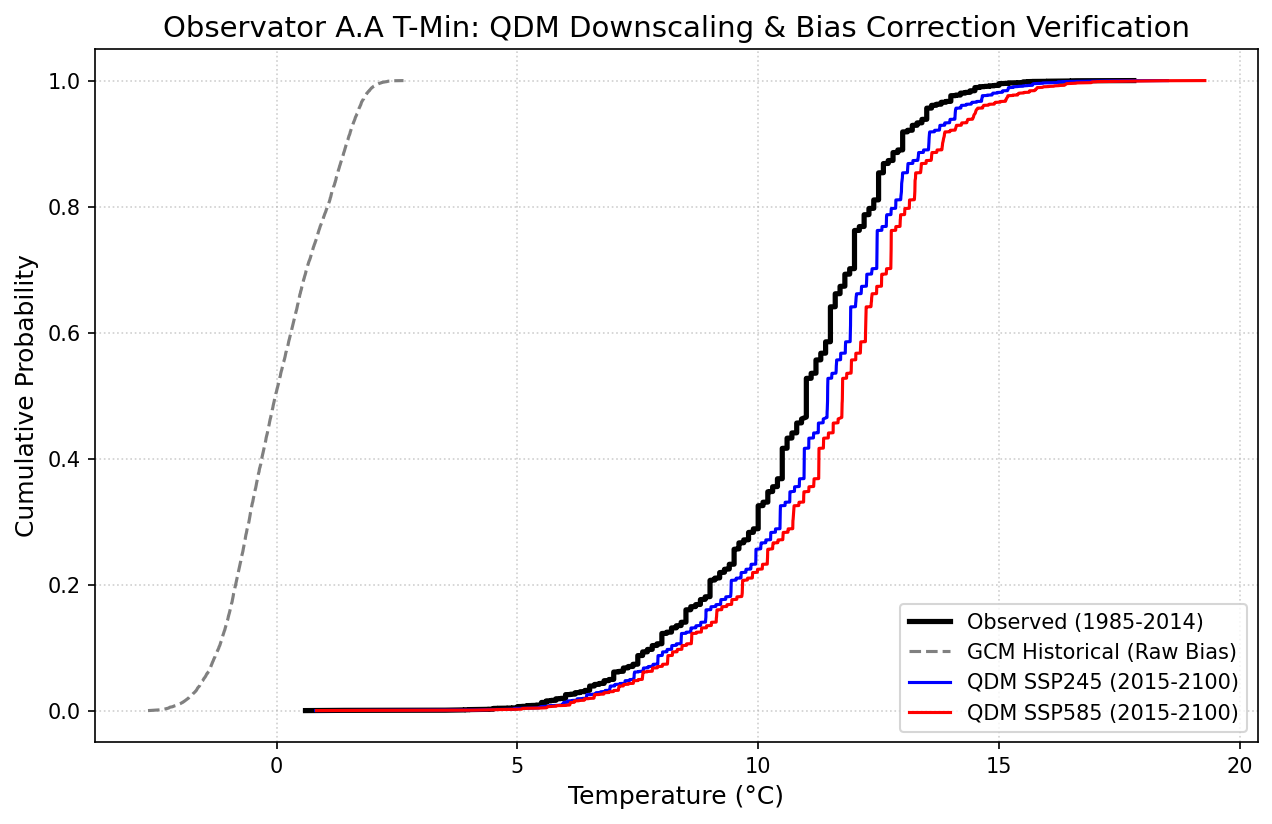

In [94]:
plt.figure(figsize=(10, 6), dpi=150)

# 1. Sort values for CDF plotting
obs_sorted = np.sort(df_obs['Temp'])
gcm_h_sorted = np.sort(df_gcm_h['Temp']) # Raw GCM from the past
ssp245_sorted = np.sort(results_245['Tmax_QDM'])
ssp585_sorted = np.sort(results_585['Tmax_QDM'])

# 2. Create probability scales
prob_hist = np.linspace(0, 1, len(obs_sorted))
prob_fut = np.linspace(0, 1, len(ssp245_sorted))

# 3. Plot lines
# Observed Baseline (Black - The standard)
plt.plot(obs_sorted, prob_hist, label='Observed (1985-2014)', color='black', linewidth=2.5)

# Historical GCM (Gray dashed - Shows the raw model bias in the past)
plt.plot(gcm_h_sorted, prob_hist, label='GCM Historical (Raw Bias)', color='gray', linestyle='--', linewidth=1.5)

# QDM Corrected Futures
plt.plot(ssp245_sorted, prob_fut, label='QDM SSP245 (2015-2100)', color='blue', linewidth=1.5)
plt.plot(ssp585_sorted, prob_fut, label='QDM SSP585 (2015-2100)', color='red', linewidth=1.5)

# 4. Formatting for Thesis
plt.title("Observator A.A T-Min: QDM Downscaling & Bias Correction Verification", fontsize=14)
plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, which='both', linestyle=':', alpha=0.6)

# Save the figure
plt.savefig("Obs_Temp_Min_QDM_Complete_Verification.png", bbox_inches='tight')
plt.show()

In [95]:
# Save results
results_245.to_excel("Obs_Tmin_SSP245_QDM_Final.xlsx", header=False)
results_585.to_excel("Obs_Tmin_SSP585_QDM_Final.xlsx", header=False)

print("Files saved: 'Mojo_Tmax_SSP245_QDM_Final.xlsx' and 'Bishoftu_Tmax_SSP585_QDM_Final.xlsx'")

Files saved: 'Mojo_Tmax_SSP245_QDM_Final.xlsx' and 'Bishoftu_Tmax_SSP585_QDM_Final.xlsx'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')